# 03 Application: Dynamic Value-at-Risk

This notebook connects the volatility forecasting models to a practical risk-management application. The main goal is to compare a model-based dynamic VaR against a rolling historical VaR benchmark.


## 1. Import packages and project utilities

The notebook uses reusable helper functions from `src/` where possible. If the helper files are not available or are incomplete, local fallback functions keep the notebook runnable.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# Allow notebooks to import modules from ../src
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


In [2]:
from src.var import compute_dynamic_var, compute_rolling_var
from src.evaluation import evaluate
print("Using VaR and evaluation helper functions from src/.")



Using VaR and evaluation helper functions from src/.


## 2. Load processed data

We load the modeling dataset created in `01_data_setup.ipynb` and the daily return series. The same 80/20 time-based train-test split is used so that the VaR test period matches the forecasting test period.


In [3]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "model_data.csv", index_col=0, parse_dates=True)
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)

feature_cols = ["vol_lag1", "vol_lag5", "vol_lag10", "vol_lag21"]
X = df[feature_cols]
y = df["target"]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

test_returns = returns["SPY"].loc[y_test.index]

df.head()


,vol,vol_lag1,vol_lag5,vol_lag10,vol_lag21,target
Date,,,,,,
2015-03-05,0.076596,0.088955,0.117697,0.138446,0.178844,0.092105
2015-03-06,0.092105,0.076596,0.106632,0.138761,0.167060,0.086748
2015-03-09,0.086748,0.092105,0.104769,0.130694,0.165992,0.104232
2015-03-10,0.104232,0.086748,0.092912,0.128510,0.161692,0.103366
2015-03-11,0.103366,0.104232,0.088955,0.128742,0.150426,0.106207


## 3. Load or recreate model-based volatility forecasts

If `model_predictions.csv` already exists from the modeling notebook, we use the saved stacking predictions directly. Otherwise, we retrain a stacking model here using time-series cross-validation.


In [5]:
pred_path = DATA_DIR / "model_predictions.csv"


predictions = pd.read_csv(pred_path, index_col=0, parse_dates=True)

    # Prefer stacking prediction if available; otherwise use the first non-actual prediction column.
pred_vol = predictions["stacking"].loc[y_test.index]

## 4. Dynamic VaR using predicted volatility

The dynamic VaR uses the model-predicted annualized volatility and converts it into a daily volatility estimate. A 5% VaR threshold is then computed using the standard normal quantile.


In [6]:
var_dynamic_5 = compute_dynamic_var(pred_vol, alpha=0.05)
violations_dynamic = test_returns < var_dynamic_5

dynamic_violation_rate = violations_dynamic.mean()

dynamic_summary = pd.DataFrame({
    "Metric": ["Expected Violation Rate", "Actual Violation Rate", "Number of Violations"],
    "Value": [0.05, dynamic_violation_rate, int(violations_dynamic.sum())]
})

dynamic_summary


,Metric,Value
0,Expected Violation Rate,0.050000
1,Actual Violation Rate,0.062626
2,Number of Violations,31.000000


## 5. Rolling historical VaR benchmark

The benchmark VaR is based on a 21-day rolling standard deviation of SPY daily returns. This benchmark does not use machine learning; it only uses recent realized volatility.


In [7]:
var_benchmark_5 = compute_rolling_var(test_returns, window=21, alpha=0.05).dropna()

common_index = var_benchmark_5.index.intersection(var_dynamic_5.index)

test_returns_common = test_returns.loc[common_index]
var_dynamic_common = var_dynamic_5.loc[common_index]
var_benchmark_common = var_benchmark_5.loc[common_index]

violations_dynamic_common = test_returns_common < var_dynamic_common
violations_benchmark_common = test_returns_common < var_benchmark_common

dynamic_rate = violations_dynamic_common.mean()
benchmark_rate = violations_benchmark_common.mean()

comparison_var = pd.DataFrame({
    "Method": ["Dynamic VaR", "Rolling Historical VaR"],
    "Violation Rate": [dynamic_rate, benchmark_rate],
    "Distance from 5%": [abs(dynamic_rate - 0.05), abs(benchmark_rate - 0.05)],
    "Number of Violations": [
        int(violations_dynamic_common.sum()),
        int(violations_benchmark_common.sum())
    ]
})

comparison_var


,Method,Violation Rate,Distance from 5%,Number of Violations
0,Dynamic VaR,0.065263,0.015263,31
1,Rolling Historical VaR,0.052632,0.002632,25


## 6. Visual comparison

The plot below compares daily SPY returns with the two VaR thresholds. Points marked with an `x` represent days when the realized return fell below the dynamic VaR estimate.


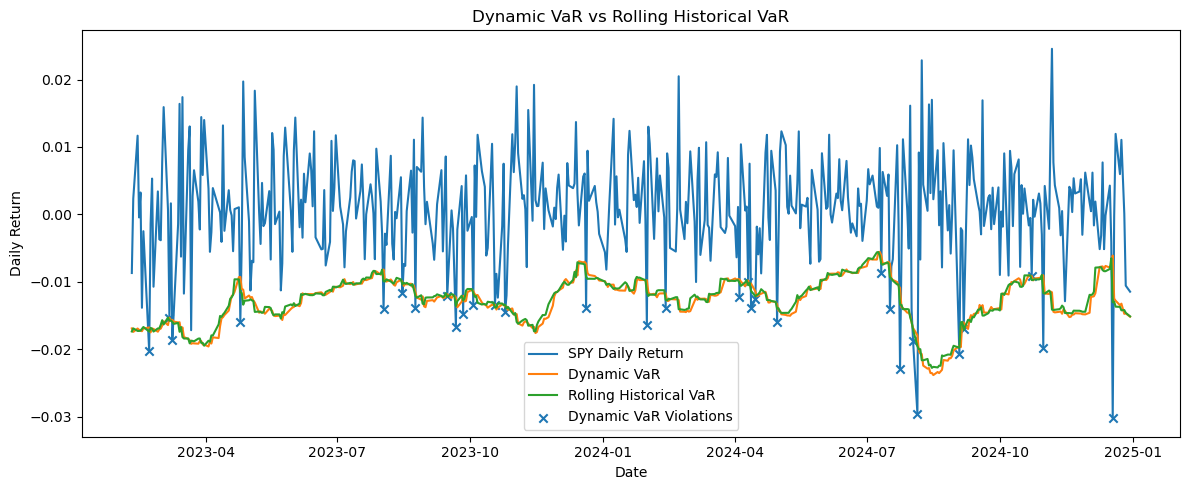

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(test_returns_common.index, test_returns_common, label="SPY Daily Return")
plt.plot(var_dynamic_common.index, var_dynamic_common, label="Dynamic VaR")
plt.plot(var_benchmark_common.index, var_benchmark_common, label="Rolling Historical VaR")

plt.scatter(
    test_returns_common.index[violations_dynamic_common],
    test_returns_common[violations_dynamic_common],
    marker="x",
    label="Dynamic VaR Violations"
)

plt.title("Dynamic VaR vs Rolling Historical VaR")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dynamic_var_vs_benchmark.png", dpi=300)
plt.show()


## 7. Interpretation

The dynamic VaR framework connects volatility forecasting to risk management. Instead of assuming a fixed or purely historical volatility level, the dynamic VaR adjusts over time based on the model's predicted volatility. A violation occurs when the realized return is lower than the VaR threshold.

The theoretical violation rate for a 5% VaR model is 5%. If the dynamic VaR violation rate is closer to 5% than the rolling historical VaR benchmark, this suggests that model-based volatility forecasts improve downside risk calibration. If the violation rate is much higher than 5%, the model underestimates tail risk; if it is much lower than 5%, the model is too conservative.

This application is important because it turns volatility forecasting into a practical financial tool. The model is no longer evaluated only by RMSE or MAE; it is also evaluated by whether it improves risk measurement in a realistic portfolio-risk setting.


## 8. Save final outputs

The comparison table and aligned VaR series are saved so they can be used in the README, report, or later strategy notebook.


In [9]:
comparison_var.to_csv(DATA_DIR / "var_comparison.csv", index=False)

var_output = pd.DataFrame({
    "SPY_Return": test_returns_common,
    "Dynamic_VaR_5": var_dynamic_common,
    "Rolling_Historical_VaR_5": var_benchmark_common,
    "Dynamic_Violation": violations_dynamic_common.astype(int),
    "Benchmark_Violation": violations_benchmark_common.astype(int)
})

var_output.to_csv(DATA_DIR / "var_backtest_series.csv")
var_output.head()


,SPY_Return,Dynamic_VaR_5,Rolling_Historical_VaR_5,Dynamic_Violation,Benchmark_Violation
Date,,,,,
2023-02-09,-0.008707,-0.016923,-0.017384,0,0
2023-02-10,0.002331,-0.017445,-0.016922,0,0
2023-02-13,0.011671,-0.016940,-0.017302,0,0
2023-02-14,-0.000460,-0.017137,-0.017304,0,0
2023-02-15,0.003242,-0.017263,-0.017261,0,0
